In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import  plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import het_arch
import matplotlib.pyplot as plt
from datetime import datetime as dt
import pytz



In [2]:
path = 'http://api.bcb.gov.br/dados/serie/bcdata.sgs.1373/dados?formato=csv'
dados = pd.read_table(path, sep=';')
dados

,data,valor
0,01/02/1993,73042
1,01/03/1993,98691
2,01/04/1993,88839
3,01/05/1993,101055
4,01/06/1993,102512
...,...,...
392,01/10/2025,247770
393,01/11/2025,219058
394,01/12/2025,184474
395,01/01/2026,159552


In [3]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   data    397 non-null    str  
 1   valor   397 non-null    int64
dtypes: int64(1), str(1)
memory usage: 6.3 KB


In [4]:
dados['data'] = pd.to_datetime(dados['data'], dayfirst=True)
dados = dados.set_index('data')
dados

,valor
data,
1993-02-01,73042
1993-03-01,98691
1993-04-01,88839
1993-05-01,101055
1993-06-01,102512
...,...
2025-10-01,247770
2025-11-01,219058
2025-12-01,184474


In [5]:
dados.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 397 entries, 1993-02-01 to 2026-02-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   valor   397 non-null    int64
dtypes: int64(1)
memory usage: 6.2 KB


<Axes: xlabel='data'>

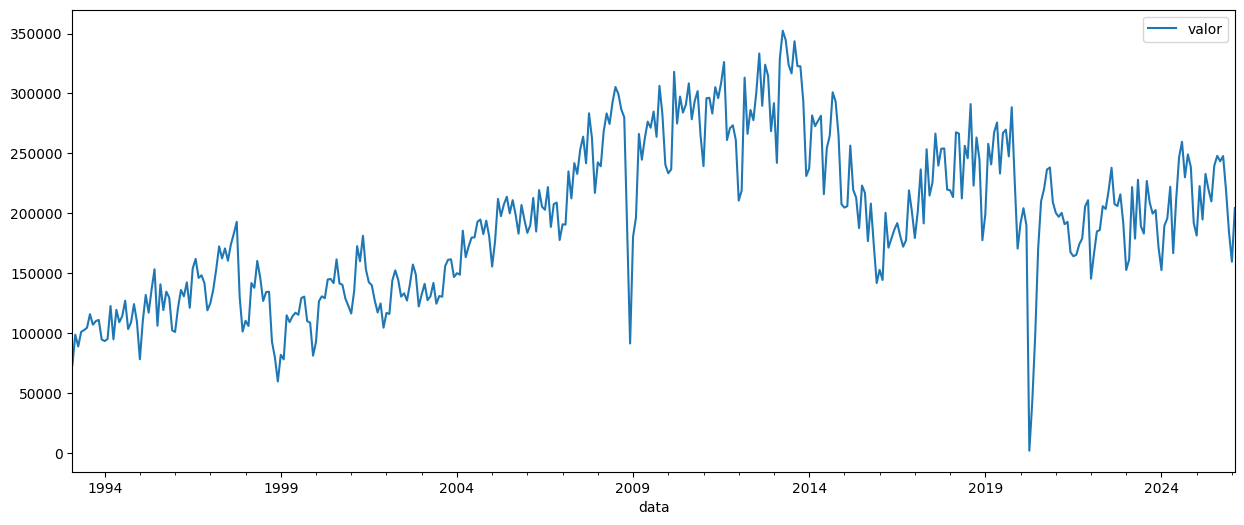

In [6]:
dados.plot(figsize=(15,6))

In [7]:
bimestral = dados.resample("2ME").mean()
bimestral.head(20)

,valor
data,
1993-02-28,73042.0
1993-04-30,93765.0
1993-06-30,101783.5
1993-08-31,110146.5
1993-10-31,108489.5
1993-12-31,102860.5
1994-02-28,94208.5
1994-04-30,108710.0
1994-06-30,114271.0


In [8]:
trimestral = dados.resample("QE").mean()
trimestral.head(15)

,valor
data,
1993-03-31,85866.500000
1993-06-30,97468.666667
1993-09-30,109094.333333
1993-12-31,105236.666667
1994-03-31,103672.333333
1994-06-30,107787.333333
1994-09-30,114866.000000
1994-12-31,114238.000000
1995-03-31,106739.666667


In [9]:
# Janela bimestral móvel
bimestre_movel = dados['valor'].rolling(window=2).mean()
bimestre_movel.head(10)

data
1993-02-01         NaN
1993-03-01     85866.5
1993-04-01     93765.0
1993-05-01     94947.0
1993-06-01    101783.5
1993-07-01    103502.5
1993-08-01    110146.5
1993-09-01    111395.0
1993-10-01    108489.5
1993-11-01    110516.0
Name: valor, dtype: float64

In [10]:
trimestre_movel = dados['valor'].rolling(window=3).mean()
trimestre_movel.head(15)

data
1993-02-01              NaN
1993-03-01              NaN
1993-04-01     86857.333333
1993-05-01     96195.000000
1993-06-01     97468.666667
1993-07-01    102686.666667
1993-08-01    107601.666667
1993-09-01    109094.333333
1993-10-01    110926.333333
1993-11-01    109340.666667
1993-12-01    105236.666667
1994-01-01     99692.666667
1994-02-01     94365.000000
1994-03-01    103672.333333
1994-04-01    104160.000000
Name: valor, dtype: float64

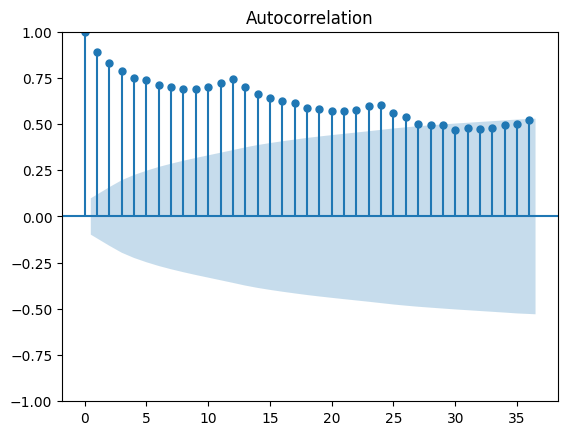

In [11]:
plot_acf(dados['valor'], lags=36)
plt.show()

In [12]:
acf_values = acf(dados['valor'], nlags=36)
acf_values

array([1.        , 0.89270527, 0.82984114, 0.78585668, 0.75041072,
       0.73799302, 0.70959723, 0.69926673, 0.69181321, 0.68848573,
       0.70306698, 0.7201789 , 0.74374679, 0.70256733, 0.66194625,
       0.63918463, 0.6244546 , 0.61640568, 0.58969898, 0.57993587,
       0.57320191, 0.57171844, 0.57529743, 0.59786286, 0.60103532,
       0.55982358, 0.54039606, 0.50278963, 0.49721651, 0.4958298 ,
       0.46988664, 0.47885389, 0.47251953, 0.4798577 , 0.49757548,
       0.4982617 , 0.52224128])

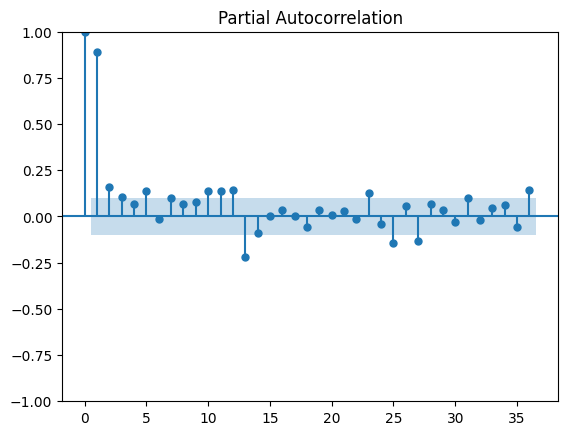

In [13]:
plot_pacf(dados['valor'], lags=36)
plt.show()

ACF: cai lentamente, o que é um sinal clássico de não estacionariedade.
PACF: pico muito forte no lag 1 depois valores pequenos espalhados. O que também é compatível com série em nível carregando tendência (estrutura persistente).


In [14]:
resultado = adfuller(dados['valor'].dropna())
print('Estatística ADF:', resultado[0])
print('p-value:', resultado[1])
print('Número de lags usados:', resultado[2])
print('Número de observações:', resultado [3])

print('\nValores Críticos:')
for chave, valor in resultado[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -1.9453906172361832
p-value: 0.31101822857381645
Número de lags usados: 13
Número de observações: 383

Valores Críticos:
1%: -3.44753973676872
5%: -2.8691160516676844
10%: -2.57080585953957


O Teste de Dickey-Fuller reforça que a série é não estacionária, tal qual foi visualizado através dos correlogramas. Isso se justifica porque o valor do teste ADF é -1,94539, que é maior que os valores críticos de 1%, 5% e 10%. Na verdade, seu p-value é de 0,3110 (31,1%).

Vamos fazer o teste KPSS.

O teste ADF pergunta se a série tem raiz unitária. O KPSS pergunta se a série é estacionária.

In [15]:
resultado = kpss(dados['valor'].dropna(), regression= 'c')

print("Estatística KPSS:", resultado[0])
print('p-value:', resultado[1])
print('Lags usados:', resultado[2])
print('\nValores críticos:')
for chave, valor in resultado[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 1.664819372500152
p-value: 0.01
Lags usados: 11

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_85520\503471880.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado = kpss(dados['valor'].dropna(), regression= 'c')


Como
H0: a série é estacionária
H1: a série não é estacionária

P-value 0.01, rejeitamos a Hipótese nula e aceitamos a hipótese alternativa. Logo, a série não é estacionária.

Vamos diferenciá-la, então.

In [16]:
pacf_values = pacf(dados['valor'], nlags=36)
pacf_values

array([ 1.        ,  0.89495958,  0.16624298,  0.10702596,  0.07030837,
        0.14650137, -0.00978685,  0.1053552 ,  0.07135227,  0.08475656,
        0.15074075,  0.14908927,  0.16302893, -0.2264463 , -0.09632815,
        0.0023082 ,  0.0396549 ,  0.00363249, -0.0593971 ,  0.03625861,
        0.00577813,  0.03166281, -0.01318167,  0.14099157, -0.04050265,
       -0.15707001,  0.06172858, -0.15045006,  0.07048689,  0.03803166,
       -0.03165226,  0.114631  , -0.02043195,  0.05425557,  0.07021779,
       -0.06749306,  0.16700143])

In [17]:
serie_diff = dados['valor'].diff().dropna()
serie_diff

data
1993-03-01    25649.0
1993-04-01    -9852.0
1993-05-01    12216.0
1993-06-01     1457.0
1993-07-01     1981.0
               ...   
2025-10-01     4377.0
2025-11-01   -28712.0
2025-12-01   -34584.0
2026-01-01   -24922.0
2026-02-01    44793.0
Name: valor, Length: 396, dtype: float64

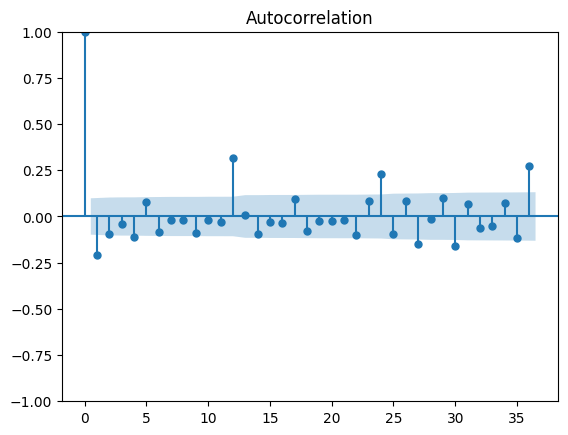

In [18]:
plot_acf(serie_diff, lags=36)
plt.show()

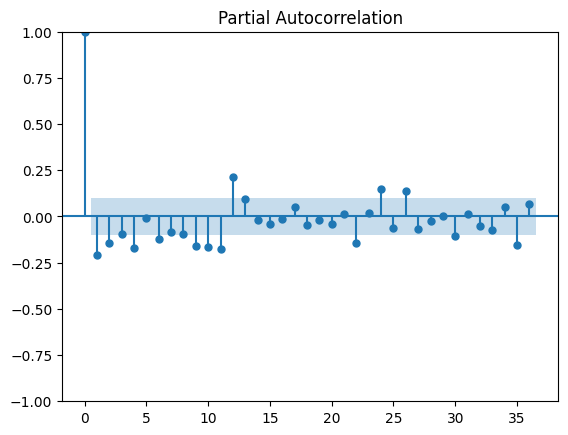

In [19]:
plot_pacf(serie_diff, lags=36)
plt.show()

ACF: após diferenciar uma vez parece ter picos nos lags 12, 24 e 36
PACF: varios lags negativos entre 1 e 8. Alguns picos leves em 12 e 24.

A série parece estacionária com possivel sazonalidade (lag12)

Uma sugestão é testar o modelo ARIMA (0, 1, 1)

Mas antes, vamos fazer os testes ADF e KPSS.

In [20]:
resultado = adfuller(serie_diff)
print('Estatística ADF:', resultado[0])
print('p-value:', resultado[1])
print('Número de lags usados:', resultado[2])
print('Número de observações:', resultado [3])

print('\nValores Críticos:')
for chave, valor in resultado[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -6.607721464985432
p-value: 6.4930482803880145e-09
Número de lags usados: 12
Número de observações: 383

Valores Críticos:
1%: -3.44753973676872
5%: -2.8691160516676844
10%: -2.57080585953957


In [21]:
resultado = kpss(serie_diff, regression= 'c')

print("Estatística KPSS:", resultado[0])
print('p-value:', resultado[1])
print('Lags usados:', resultado[2])
print('\nValores críticos:')
for chave, valor in resultado[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.09409295454911103
p-value: 0.1
Lags usados: 18

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_85520\355947642.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado = kpss(serie_diff, regression= 'c')


Tanto pelo teste ADF, quanto pelo teste KPSS não rejeitamos a hipótese de estacionariedade dos dados em primeira diferença.

Uma sugestão para esse modelo é usar um:

SARIMA (0,1,1)(0,1,1,12)

ACF corta no lag 1, sazonalidade 12, 24, 36 e uma diferencial.

Modelos Alternativos são:

a) ARIMA(0,1,1)
b) ARIMA(1,1,1)
C) SARIMA(1,1,1)(0,1,1,12)

Vamos testar a sazonalidade, se é multiplicativa ou aditiva.

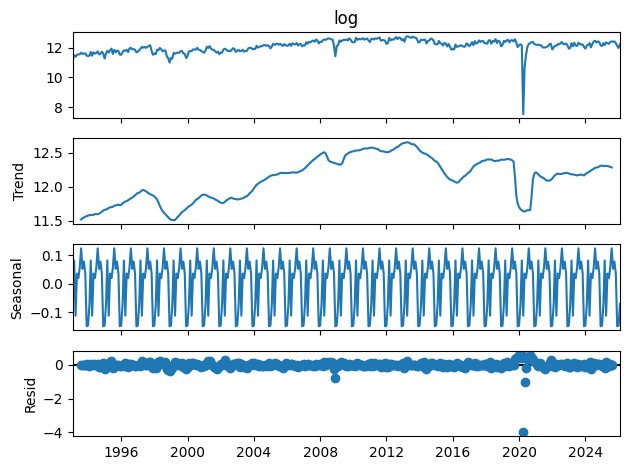

In [22]:
dados['log'] = np.log(dados['valor'])
decomp_log = seasonal_decompose(dados['log'], model='addtive', period=12)
figura = decomp_log.plot()
plt.show()

Vê-se que o modelo log (modelo multiplicativo) é estável. 

A Tendência cresce até 2014, aproximadamente, depois cai. Estabilizando-se após 2021.

A sazonalidade tem o mesmo formato ao longo dos anos, com periodicidade clara de 12 meses.

Resíduos mostram estabilidade ao redor de 0, porém com efeitos para baixo em 208 e, principalmente, em 2020. Mostrando a presença de outliers nesses períodos.

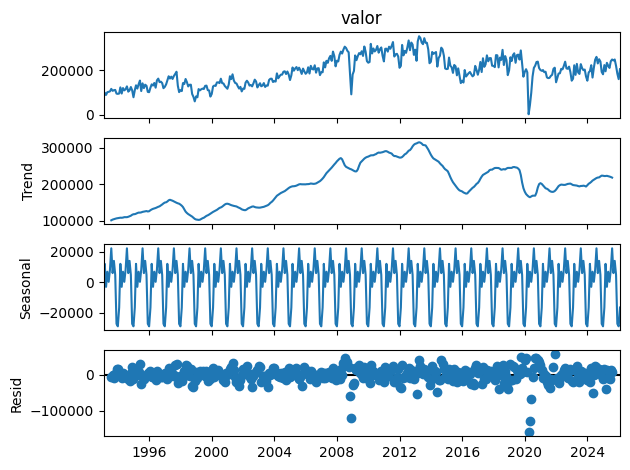

In [23]:
decomp = seasonal_decompose(dados['valor'], model = 'additive', period=12)
fig = decomp.plot()
plt.show()


Olhando os dados em log (Modelo Multiplicativo) e o Modelo Aditivo, observa-se que os dados são mais estáveis no modelo multiplicativo, o qual explica melhor os dados.

Desse modo, o modelo que deve ser usado é um modelo SARIMA em log.

In [24]:
modelo = SARIMAX(dados['log'], order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False)

result_model = modelo.fit()
print(result_model.summary())

c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                log   No. Observations:                  397
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -65.885
Date:                            Tue, 24 Mar 2026   AIC                            141.769
Time:                                    12:03:03   BIC                            161.337
Sample:                                02-01-1993   HQIC                           149.542
                                     - 02-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4042      0.047      8.681      0.000       0.313       0.495
ma.L1         -0.9135      0.037   

ar.S.L12 com p-value de 0.736 mostra que o modelo pode não ter sazonalidade com lag 12. 

Skew, Kurtosis e Jarque-Bera com probabilidade 0.00 mostram que os resíduos não são normais (há presença de outliers). Provavelmente devido às crises de 2008 (subprime) e 2020 (pandemia).

Testa-se, agora, um modelo SARIMA (1,1,1).

In [25]:
modelo_sem_sazonalidade = SARIMAX(dados['log'], order=(1,1,1), seasonal_order=(0,0,0,0), enforce_stationarity=False, enforce_invertibility=False)
resultado_sem_sazonal = modelo_sem_sazonalidade.fit()

print(resultado_sem_sazonal.summary())


                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                  397
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -58.581
Date:                Tue, 24 Mar 2026   AIC                            123.163
Time:                        12:03:03   BIC                            135.092
Sample:                    02-01-1993   HQIC                           127.890
                         - 02-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4108      0.040     10.159      0.000       0.332       0.490
ma.L1         -0.9233      0.032    -28.619      0.000      -0.987      -0.860
sigma2         0.0786      0.001    137.900      0.0

c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Akayke (AIC) e o critério de Schwarz (BIC) são melhores no modelo sem sazonalidade. Mas o efeito sobre heterocedasticidade, assimetria e curtose não mostram normalidade. Ou seja, a presença de outliers ainda traz problemas ao modelo.

Apesar do modelo sem sazonalidade ser mais simples (dado que Akayke e Schwarz são menores) ele ignora um padrão que é realístico, o da presença de sazonalidade.

Testa-se, agora, o modelo SARIMAX (1,1,1)(0,1,1,12)

In [26]:
modelo2 = SARIMAX(dados['log'], order=(1,1,1), seasonal_order=(0,1,1,12), enforce_stationarity=False, enforce_invertibility=False)

resultado2 = modelo2.fit()
print(resultado2.summary())

c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                log   No. Observations:                  397
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -62.067
Date:                            Tue, 24 Mar 2026   AIC                            132.134
Time:                                    12:03:04   BIC                            147.788
Sample:                                02-01-1993   HQIC                           138.352
                                     - 02-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4105      0.046      8.912      0.000       0.320       0.501
ma.L1         -0.9179      0.036   

Os problemas nos resíduos não sumiram.

Os modelos ARIMA/SARIMA testados explicam a dependência temporal, a tendência e a sazonalidade. Mas possuem problemas nos resíduos (há choques extremos em 2008 e 2020 que afetam a variância/volatilidade da série temporal da produção de veículos no Brasil).

Trata-se, primeiramente, os resíduos por meio de dummmies.

In [27]:
dados['dummy_2008'] = (dados.index.year == 2008).astype(int)
dados['dummy_2020'] = (dados.index.year == 2020).astype(int)

In [28]:
mmodelo3 = SARIMAX(dados['log'], exog=dados[['dummy_2008', 'dummy_2020']], order=(1,1,1), seasonal_order=(0,1,1,12), enforce_stationarity=False, enforce_invertibility=False)
resultado3 = mmodelo3.fit()

print(resultado3.summary())

c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                log   No. Observations:                  397
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -56.462
Date:                            Tue, 24 Mar 2026   AIC                            124.923
Time:                                    12:03:04   BIC                            148.405
Sample:                                02-01-1993   HQIC                           134.250
                                     - 02-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dummy_2008    -0.0398      0.236     -0.169      0.866      -0.502       0.422
dummy_2020    -0.4742      0.121   

A dummy_2008 não é significativa. Mas a dummy_2020, é. Isso demonstra o impacto estrutural da pandemia na série de dados da fabricação de veículos.

Ljung_Box ficou com probabilidade excelente (1.00). Isso significa que os resíduos não tem autocorrelação e a estrutura temporal está bem capturada.

Próximo passo é retirar dummy_2008 do modelo.

In [29]:
modelo4 = SARIMAX(dados['log'], exog=dados['dummy_2020'], order=(1,1,1), seasonal_order=(0,1,1,12), enforce_stationarity=False, enforce_invertibility=False)
resultado4 = modelo4.fit()

print(resultado4.summary())

c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                log   No. Observations:                  397
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -56.508
Date:                            Tue, 24 Mar 2026   AIC                            123.016
Time:                                    12:03:05   BIC                            142.583
Sample:                                02-01-1993   HQIC                           130.788
                                     - 02-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dummy_2020    -0.4750      0.120     -3.952      0.000      -0.711      -0.239
ar.L1          0.3510      0.040   

em todos os modelos SARIMAX testados, há problemas de heteroscedasticidade e presença de outliers. A solução é tratar os resíduos via ARCH/GARCH.

In [30]:
residuos = resultado4.resid.dropna()

In [31]:
teste_arch = het_arch(residuos)
print(teste_arch)

(np.float64(0.5402508853581259), np.float64(0.9999904235686994), 0.05256286931822031, 0.9999911953213605)


Pelo LM p-value e pelo F p-value não se rejeita a hipótese nula de não haver efeito ARCH (variância constante). Ou seja, não há heterocedasticidade condicional, os resíduos são homocedásticos.

Assim, mesmo com a não-normalidade dos resíduos, verificada, por exemplo, pela assimetria diferente de zero e pela curtose maior que 3, não há indícios de heterocedasticidade condicional.

No entanto, vale observar que a não normalidade dos resíduos cria problemas na interpretação dos intervalos de confiança e os testes p-values podem ser distorcidos.

Como o objetivo é fazer a previsão da fabricação de veículos no Brasil, pode-se ignorar esses problemas e seguir adiante. Para tanto, usar-se-á o modelo SARIMAX (1,1,1)(0,1,1,12) Ccom dummy em 2020, dado o menor critério de Akayke (AIC) e de Schwartz (BIC).

In [32]:
exog_futuro = pd.DataFrame({'dummy_2020':[0]*12})

forecast_log = resultado4.forecast(steps=12, exog=exog_futuro)
forecast_nivel = np.exp(forecast_log)

forecast_nivel



2026-03-01    234366.537813
2026-04-01    187087.640512
2026-05-01    220692.646207
2026-06-01    219267.660107
2026-07-01    230491.451197
2026-08-01    247586.858723
2026-09-01    231022.166197
2026-10-01    238729.595899
2026-11-01    229483.412258
2026-12-01    191485.530209
2027-01-01    188892.776347
2027-02-01    206245.904204
Freq: MS, Name: predicted_mean, dtype: float64

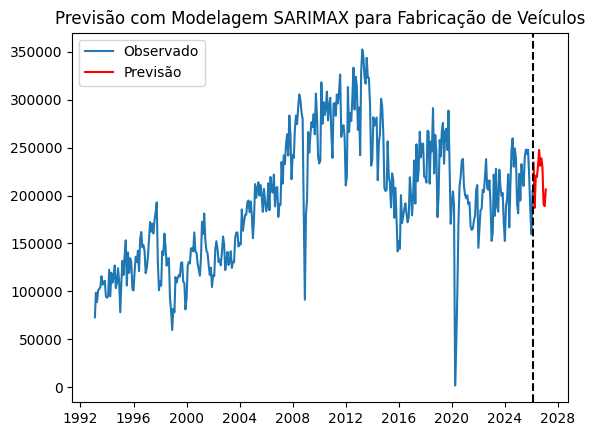

In [33]:
plt.Figure(figsize=(15, 6))
plt.plot(dados['valor'], label='Observado')
plt.plot(forecast_nivel, label="Previsão", color='red')

plt.axvline(x=dados.index[-1], color='black', linestyle='--')

plt.legend()
plt.title('Previsão com Modelagem SARIMAX para Fabricação de Veículos')
plt.show()